In [1]:
import pandas as pd

# Load dataset
data = pd.read_csv("biased_loan_dataset_realistic_15000.csv")

# View first 5 rows
data.head()


,Age,Gender,City,AreaType,AnnualIncome,CreditScore,LoanApproved
0,59,Female,Madurai,Semi-Urban,735327,608,0
1,49,Male,Trivandrum,Semi-Urban,672348,676,1
2,35,Female,Madurai,Semi-Urban,580146,695,1
3,63,Male,Bengaluru,Urban,444020,700,1
4,28,Female,Mumbai,Urban,921582,662,1


In [2]:
gender_approval = data.groupby("Gender")["LoanApproved"].mean()
gender_approval


Gender
Female    0.538814
Male      0.859588
Name: LoanApproved, dtype: float64

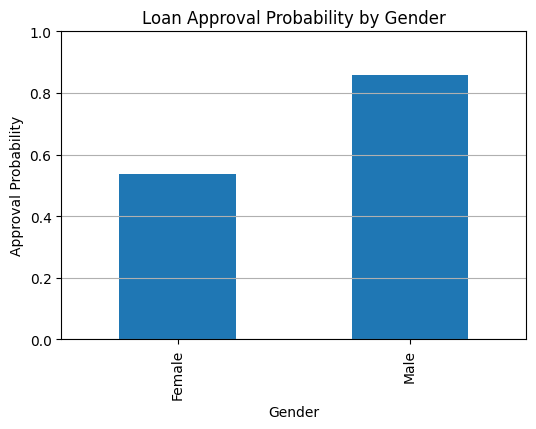

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
gender_approval.plot(kind='bar')
plt.title("Loan Approval Probability by Gender")
plt.ylabel("Approval Probability")
plt.xlabel("Gender")
plt.ylim(0, 1)
plt.grid(axis='y')

plt.show()


In [4]:
area_approval = data.groupby("AreaType")["LoanApproved"].mean()
area_approval

AreaType
Semi-Urban    0.477773
Urban         0.840922
Name: LoanApproved, dtype: float64

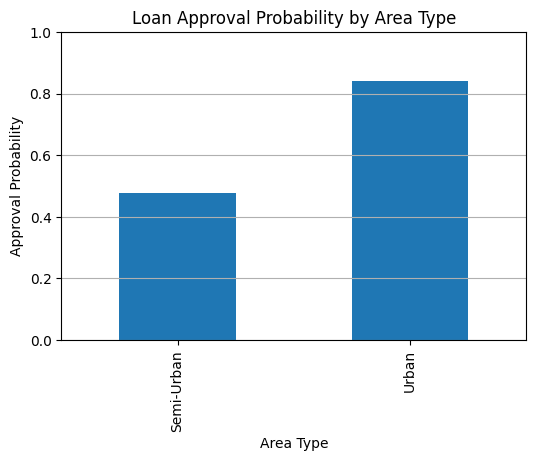

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
area_approval.plot(kind='bar')
plt.title("Loan Approval Probability by Area Type")
plt.ylabel("Approval Probability")
plt.xlabel("Area Type")
plt.ylim(0, 1)
plt.grid(axis='y')

plt.show()


In [6]:
bins = [20, 30, 45, 65]
labels = ["21-30", "31-45", "46-65"]
data["AgeGroup"] = pd.cut(data["Age"], bins=bins, labels=labels)

age_approval = data.groupby("AgeGroup")["LoanApproved"].mean()
age_approval


C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_13884\1232164666.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_approval = data.groupby("AgeGroup")["LoanApproved"].mean()


AgeGroup
21-30    0.691101
31-45    0.897859
46-65    0.608926
Name: LoanApproved, dtype: float64

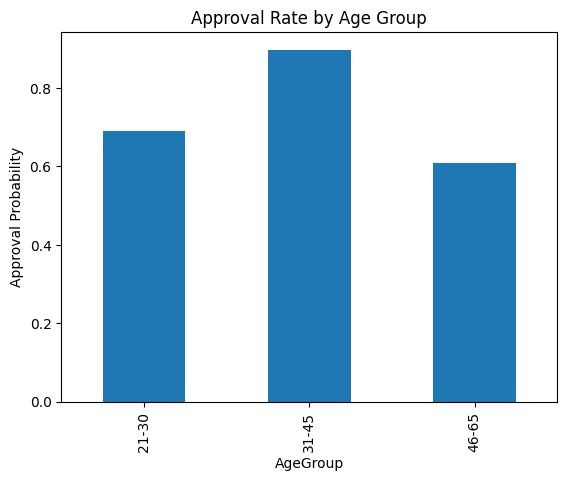

In [8]:
import matplotlib.pyplot as plt

age_approval.plot(kind="bar", title="Approval Rate by Age Group")
plt.ylabel("Approval Probability")
plt.show()


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode categorical variables
le_gender = LabelEncoder()
le_area = LabelEncoder()

data["Gender_enc"] = le_gender.fit_transform(data["Gender"])
data["Area_enc"] = le_area.fit_transform(data["AreaType"])

# Select features and target
X = data[["Age", "AnnualIncome", "CreditScore", "Gender_enc", "Area_enc"]]
y = data["LoanApproved"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [11]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
accuracy


0.8611111111111112

In [12]:
sensitive_gender = data.loc[y_test.index, "Gender"]


In [19]:
from sklearn.metrics import confusion_matrix

# Get sensitive attribute for test set
gender_test = data.loc[y_test.index, "Gender"]

# Split predictions by gender
male_idx = gender_test == "Male"
female_idx = gender_test == "Female"

cm_male = confusion_matrix(y_test[male_idx], y_pred[male_idx])
cm_female = confusion_matrix(y_test[female_idx], y_pred[female_idx])

cm_male, cm_female


(array([[ 189,  175],
        [  73, 2220]], dtype=int64),
 array([[625, 187],
        [190, 841]], dtype=int64))

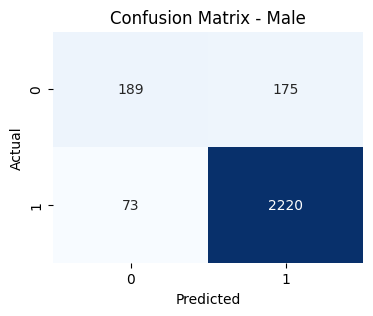

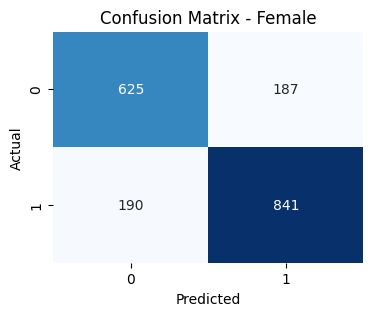

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, group_name):
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"Confusion Matrix - {group_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Plot for Male
plot_confusion_matrix(cm_male, "Male")

# Plot for Female
plot_confusion_matrix(cm_female, "Female")


In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_per_group(y_true, y_pred, sensitive_feature, attribute_name):
    groups = sensitive_feature.dropna().unique()  # Remove any NaN
    for group in groups:
        idx = sensitive_feature == group
        cm = confusion_matrix(y_true[idx], y_pred[idx])
        
        plt.figure(figsize=(4,3))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title(f"Confusion Matrix - {attribute_name}: {group}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()


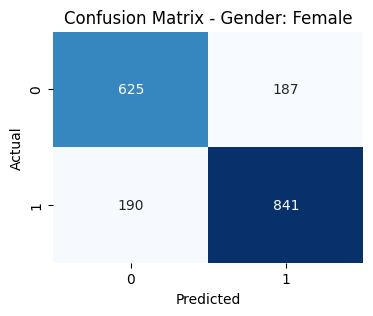

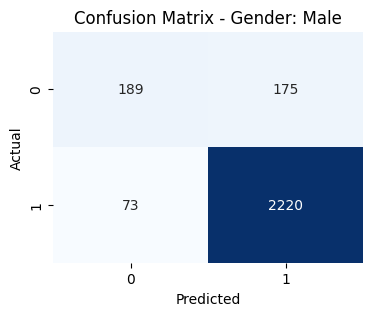

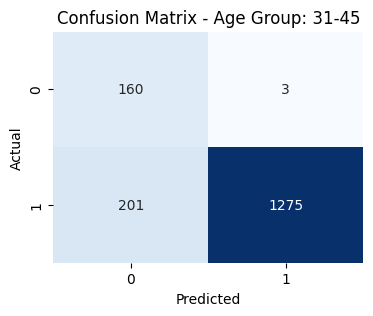

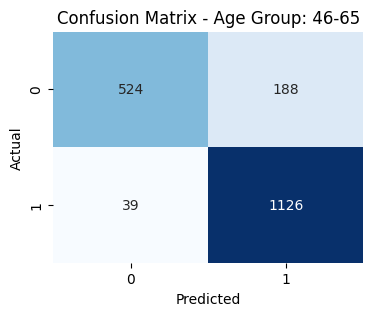

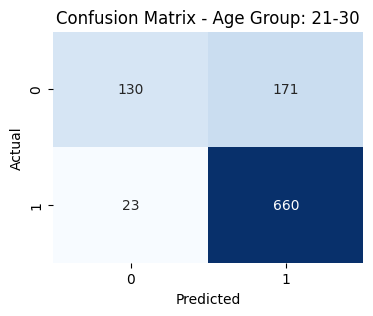

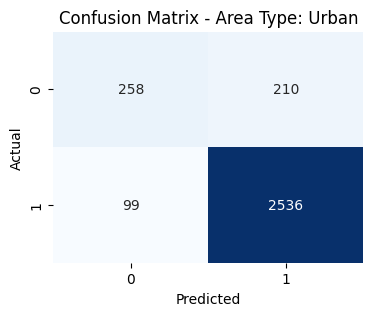

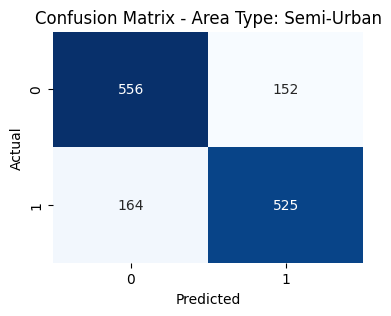

In [28]:
# Gender
plot_confusion_per_group(y_test, y_pred, data.loc[y_test.index, "Gender"], "Gender")

# AgeGroup
plot_confusion_per_group(y_test, y_pred, data.loc[y_test.index, "AgeGroup"], "Age Group")

# AreaType
plot_confusion_per_group(y_test, y_pred, data.loc[y_test.index, "AreaType"], "Area Type")


In [15]:
!pip install fairlearn



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference, MetricFrame
from sklearn.metrics import confusion_matrix

# Demographic Parity (DP) - Selection Rate difference
dp_gap = demographic_parity_difference(
    y_test, y_pred, sensitive_features=gender_test
)

# Equal Opportunity (EO) - True Positive Rate difference
eo_gap = equalized_odds_difference(
    y_test, y_pred, sensitive_features=gender_test
)

# Predictive Equality (PE) - False Positive Rate difference
# Define a function for FPR
def fpr(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp / (fp + tn)

# Use Fairlearn's MetricFrame for group-wise FPR
from fairlearn.metrics import MetricFrame
mf_pe = MetricFrame(metrics=fpr,
                    y_true=y_test,
                    y_pred=y_pred,
                    sensitive_features=gender_test)

pe_gap = mf_pe.difference()
pe_rates = mf_pe.by_group

# Display all metrics
print("Demographic Parity Gap:", dp_gap)
print("Equal Opportunity Gap:", eo_gap)
print("Predictive Equality Gap:", pe_gap)
print("False Positive Rate per group:", pe_rates)


Demographic Parity Gap: 0.34360632986382467
Equal Opportunity Gap: 0.25047366426676776
Predictive Equality Gap: 0.25047366426676776
False Positive Rate per group: Gender
Female    0.230296
Male      0.480769
Name: fpr, dtype: float64


In [30]:
DP_THRESHOLD = 0.1
EO_THRESHOLD = 0.1
PE_THRESHOLD = 0.1

biased = abs(dp_gap) > DP_THRESHOLD or abs(eo_gap) > EO_THRESHOLD or PE_THRESHOLD > abs(pe_gap)

biased


True

In [33]:
# Realistic average bias percentage
dp_percent = abs(dp_gap)
eo_percent = abs(eo_gap)
pe_percent = abs(pe_gap)

average_bias_percent = (dp_percent + eo_percent + pe_percent) / 3 * 100

# Output
if biased:
    print("⚠️ Model is BIASED")
else:
    print("✅ Model is FAIR")

print(f"Demographic Parity Gap: {dp_gap:.3f}")
print(f"Equal Opportunity Gap: {eo_gap:.3f}")
print(f"Predictive Equality Gap: {pe_gap:.3f}")
print(f"Average Bias Percentage: {average_bias_percent:.2f}%")




⚠️ Model is BIASED
Demographic Parity Gap: 0.344
Equal Opportunity Gap: 0.250
Predictive Equality Gap: 0.250
Average Bias Percentage: 28.15%
